In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
from scipy import stats
from google.colab import files

In [2]:
dataset = files.upload()

Saving EnergyEfficiency.csv to EnergyEfficiency.csv


In [3]:
df = pd.read_csv('EnergyEfficiency.csv')

**Exercise 1**

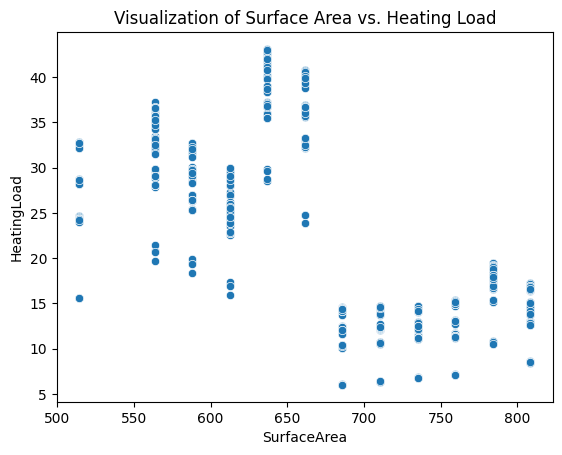

In [5]:
#Question1 Answer
sns.scatterplot(data=df, x="SurfaceArea", y="HeatingLoad")
plt.title("Visualization of Surface Area vs. Heating Load")
plt.show()

In [8]:
#Pearson Corelation
stats.pearsonr(df["SurfaceArea"], df["HeatingLoad"])

PearsonRResult(statistic=np.float64(-0.6581202267776216), pvalue=np.float64(1.6869072902148724e-96))

Q2 Answer: The correlation is negative and strong, and
it is highly statistically significant because the p-value is well below 0.05. Conceptually, this does not make sense at first glance. We would normally expect a building with a larger surface area to lose heat faster and therefore require a higher heating load

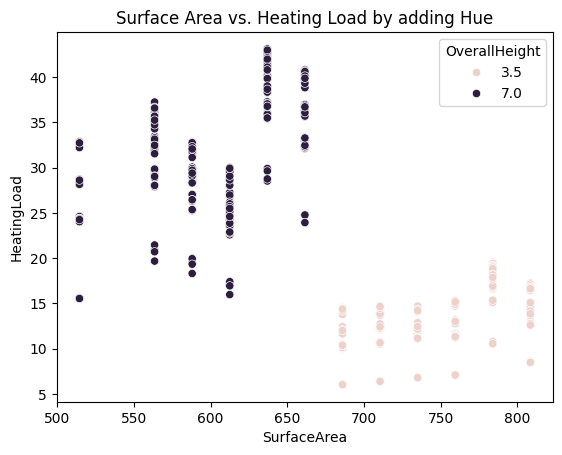

In [11]:
sns.scatterplot(data=df, x="SurfaceArea", y="HeatingLoad", hue="OverallHeight")
plt.title("Surface Area vs. Heating Load by adding Hue")
plt.show()

Q3 Answer: It changes the interpretion entirely by adding Hue. The data is split into distinct clusters based on height. Taller buildings (which happen to have smaller surface areas) require significantly more energy to heat. Shorter buildings (which have larger surface areas) require less heating load overall. The negative correlation we saw in Question 2 was simply capturing the difference between tall and short buildings, rather than the true relationship between surface area and heating load.

Q4 Answer: Training a simple linear regression model using OLS

In [12]:
import statsmodels.api as sm

In [13]:
X = df["SurfaceArea"]

In [15]:
X

,SurfaceArea
0,514.5
1,514.5
2,514.5
3,514.5
4,563.5
...,...
763,784.0
764,808.5
765,808.5
766,808.5


In [16]:
X = sm.add_constant(X)

In [17]:
X

,const,SurfaceArea
0,1.0,514.5
1,1.0,514.5
2,1.0,514.5
3,1.0,514.5
4,1.0,563.5
...,...,...
763,1.0,784.0
764,1.0,808.5
765,1.0,808.5
766,1.0,808.5


In [18]:
Y = df["HeatingLoad"]
Y

,HeatingLoad
0,15.55
1,15.55
2,15.55
3,15.55
4,20.84
...,...
763,17.88
764,16.54
765,16.44
766,16.48


In [19]:
linreg_model = sm.OLS(Y, X).fit()

In [20]:
linreg_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:            HeatingLoad   R-squared:                       0.433
Model:                            OLS   Adj. R-squared:                  0.432
Method:                 Least Squares   F-statistic:                     585.3
Date:                Sat, 14 Mar 2026   Prob (F-statistic):           1.69e-96
Time:                        06:24:07   Log-Likelihood:                -2646.6
No. Observations:                 768   AIC:                             5297.
Df Residuals:                     766   BIC:                             5306.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
===============================================================================
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const          72.9454      2.111     34.554      0.000      68.801      77.090
SurfaceArea    -0.0754      0.003    -24.192      0.000      -0.082      -0.069
==============================================================================
Omnibus:                       37.973   Durbin-Watson:                   0.321
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               42.851
Skew:                           0.576   Prob(JB):                     4.95e-10
Kurtosis:                       2.890   Cond. No.                     5.21e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 5.21e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

Q5 Ans: According to the OLS model, when the SurfaceArea goes up by 1 unit, the HeatingLoad changes by -0.0754 units.

Q6 Ans: linear regression line to a scatterplot of SurfaceArea and HeatingLoad

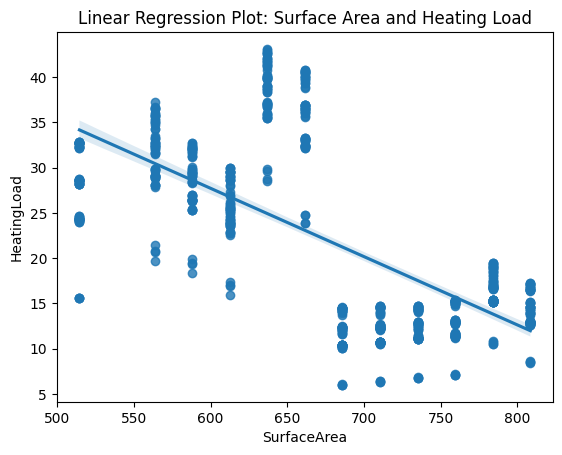

In [21]:
sns.regplot(data=df, x="SurfaceArea", y="HeatingLoad")
plt.title("Linear Regression Plot: Surface Area and Heating Load")
plt.show()

Q7 Ans: Evaluaions of Model  using R squared

In [22]:
linreg_model.rsquared

np.float64(0.433122232893828)

The model achieved an R-squared of 0.433122232893828. This means that only 43% of the variation in Heating Load is explained by the Surface Area. This indicates the model is not very good on its own, which makes sense because we already discovered that building height is a massive missing factor